In [1]:
import os
import sys
from datetime import datetime
import itertools

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from pinns import build_models
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


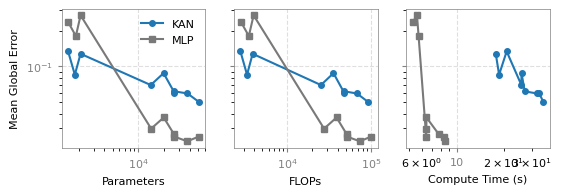

Cleaned trade-off figure successfully saved to figures/accuracy_efficiency_tradeoff_cleaned.svg


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# =========================================================
# Load Data
# =========================================================
results_dir = "results_accuracy_efficiency"
csv_path = os.path.join(results_dir, "summary_metrics.csv")
df = pd.read_csv(csv_path)

# =========================================================
# Plotting (1x3 Panel Layout with Independent Sorting)
# =========================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(6.3, 1.8),
    sharey=True
)

axis_color = "gray"

# Helper function to plot smoothly sorted lines
def plot_trend(ax, df_kan, df_mlp, x_col, label_loc="upper right"):
    # Sort independently by the target X-axis column
    kan_sorted = df_kan.sort_values(x_col)
    mlp_sorted = df_mlp.sort_values(x_col)
    
    ax.plot(kan_sorted[x_col], kan_sorted["mean_global_error"], marker='o', color='#1f77b4', lw=1.5, ms=4, label="KAN")
    ax.plot(mlp_sorted[x_col], mlp_sorted["mean_global_error"], marker='s', color='#797979', lw=1.5, ms=4, label="MLP")
    ax.set_xscale('log')
    ax.set_yscale('log')

# Panel 1: Parameters vs Accuracy
plot_trend(axes[0], df[df["model_type"] == "KAN"], df[df["model_type"] == "MLP"], "parameters")
axes[0].set_xlabel("Parameters", fontsize=8)
axes[0].set_ylabel("Mean Global Error", fontsize=8)
axes[0].legend(frameon=False, fontsize=8, loc="upper right")

# Panel 2: FLOPs vs Accuracy
plot_trend(axes[1], df[df["model_type"] == "KAN"], df[df["model_type"] == "MLP"], "flops")
axes[1].set_xlabel("FLOPs", fontsize=8)
 
# Panel 3: Compute Time vs Accuracy
plot_trend(axes[2], df[df["model_type"] == "KAN"], df[df["model_type"] == "MLP"], "compute_time_sec")
axes[2].set_xlabel("Compute Time (s)", fontsize=8)
#axes[2].set_title("(c) Wall-Clock Time", fontsize=10, fontweight='bold')

# ---> ADD THIS LINE TO CLEAN UP THE TICKS <---
axes[2].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:g}'))
 
# =========================================================
# Styling & Formatting
# =========================================================
for ax in axes:
    ax.tick_params(axis="both", labelsize=8, colors=axis_color)
    ax.grid(True, linestyle='--', alpha=0.4)
    for spine in ax.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(0.5)

plt.subplots_adjust(wspace=0.2)

os.makedirs("figures", exist_ok=True)
fig_path = "figures/accuracy_efficiency_tradeoff_cleaned.svg"
plt.savefig(fig_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Cleaned trade-off figure successfully saved to {fig_path}")